In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sms
from datetime import datetime
plt.style.use('dark_background')

In [32]:
df = pd.read_csv(r"./Alcohol_Sales.csv")
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d')
df.set_index('DATE',inplace=True)
df.sort_index()
df.rename(columns={'S4248SM144NCEN':'Sales'},inplace=True)
df.head()

,Sales
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


In [33]:
df.tail(10)

,Sales
DATE,
2018-04-01,11919
2018-05-01,14138
2018-06-01,14583
2018-07-01,12640
2018-08-01,14257
2018-09-01,12396
2018-10-01,13914
2018-11-01,14174
2018-12-01,15504


<Axes: xlabel='DATE'>

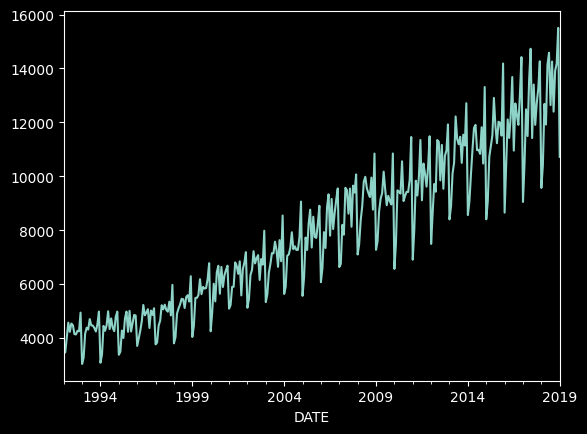

In [34]:
df['Sales'].plot()

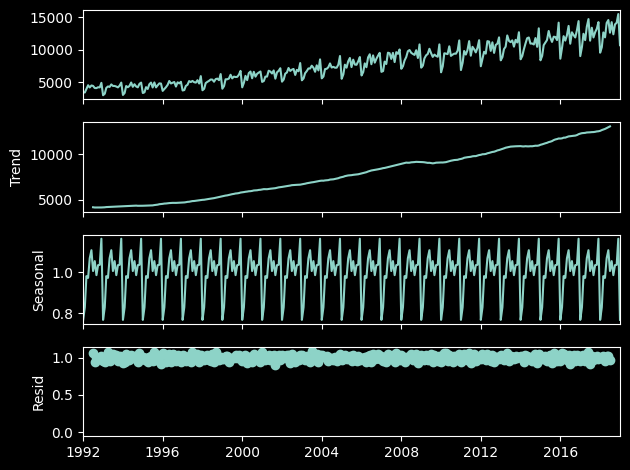

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose
res = seasonal_decompose(df, model='multiplicative')
res.plot()
plt.show()

In [36]:
from statsmodels.tsa.stattools import adfuller
r = adfuller(df['Sales'])
r[1]

0.9987196267088919

In [37]:
df['Sales_1'] = df['Sales']-df['Sales'].shift()
r = adfuller(df['Sales_1'].dropna())
r[1]

0.0003408284921170404

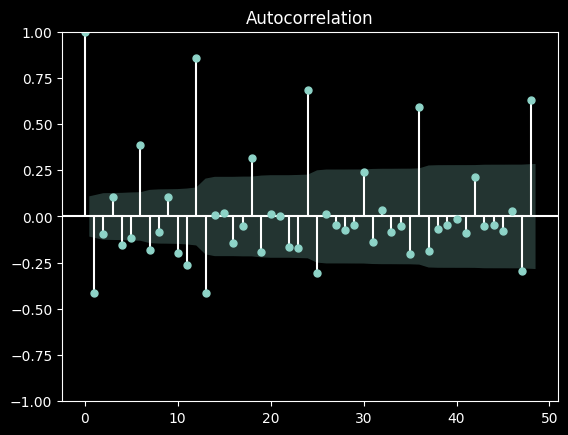

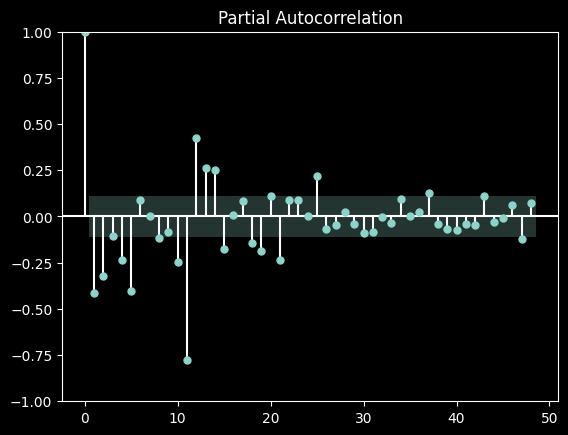

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf_plot = plot_acf(df['Sales_1'].dropna(),lags=48)
pacf_plot = plot_pacf(df['Sales_1'].dropna(),lags=48)

In [39]:
df['Sales_S1'] = df['Sales']-df['Sales'].shift(12)
r = adfuller(df['Sales_S1'].dropna())
r[1]<0.05

True

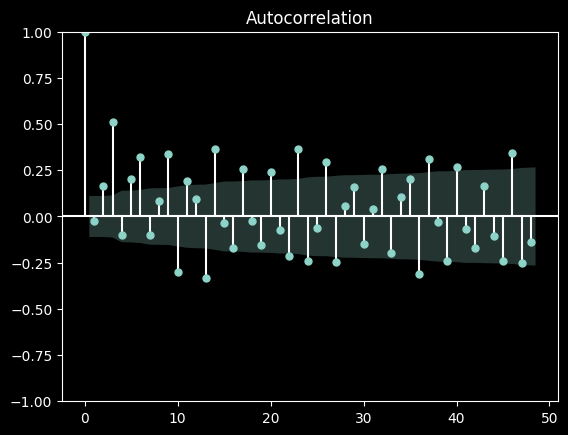

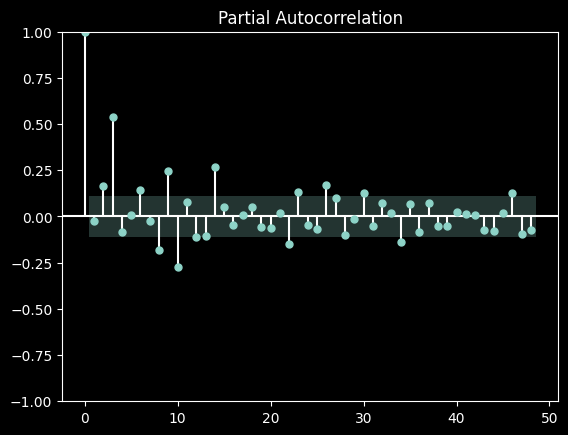

In [40]:
acf_plot = plot_acf(df['Sales_S1'].dropna(),lags=48)
pacf_plot = plot_pacf(df['Sales_S1'].dropna(),lags=48)

<Axes: xlabel='DATE'>

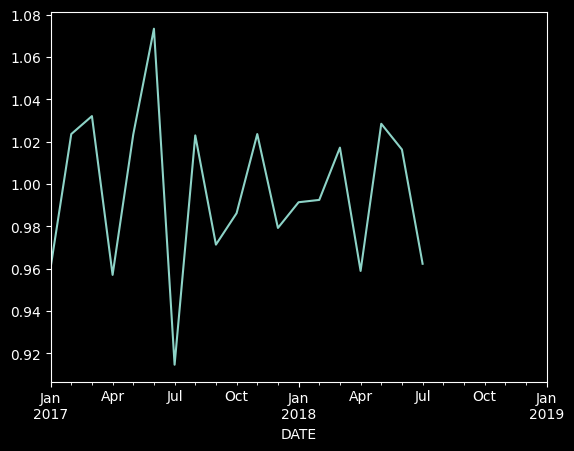

In [41]:
df['Seasonality'] = res.seasonal
df['Trend'] = res.trend
df['Residual'] = res.resid
df['Residual'][datetime(2017,1,1):datetime(2019,1,1)].plot()

In [42]:
df['Trend_1'] = df['Trend']-df['Trend'].shift(1)
r = adfuller(df['Trend_1'].dropna())
r[1]<0.05

False

In [43]:
df['Trend_2'] = df['Trend_1']-df['Trend_1'].shift(1)
r = adfuller(df['Trend_2'].dropna())
r[1]

1.6226883193988335e-06

<Axes: xlabel='DATE'>

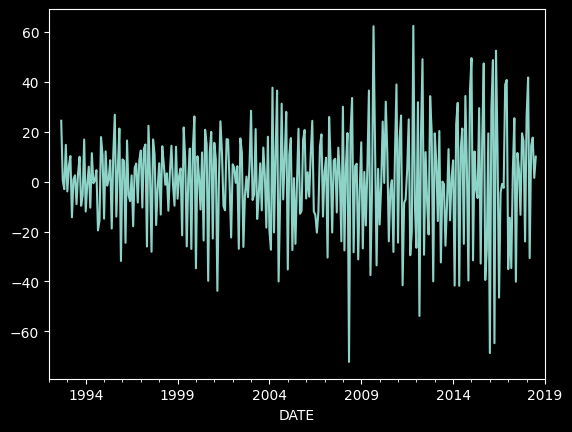

In [44]:
df['Trend_2'].plot()

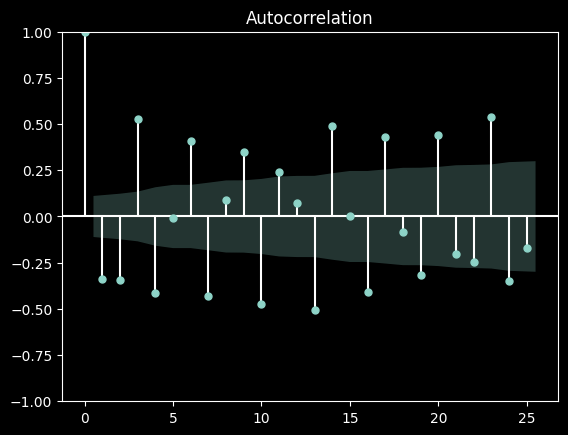

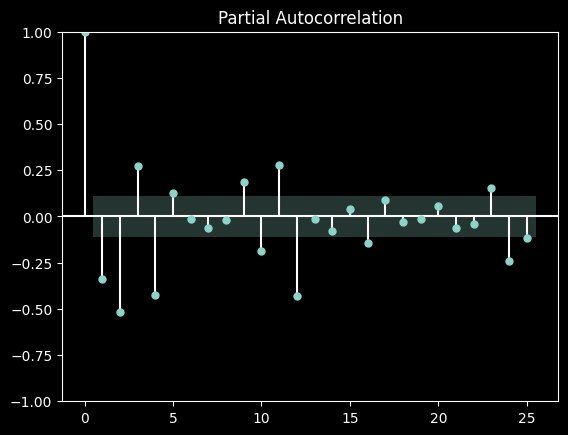

In [45]:
acf = plot_acf(df['Trend_2'].dropna())
pacf = plot_pacf(df['Trend_2'].dropna())

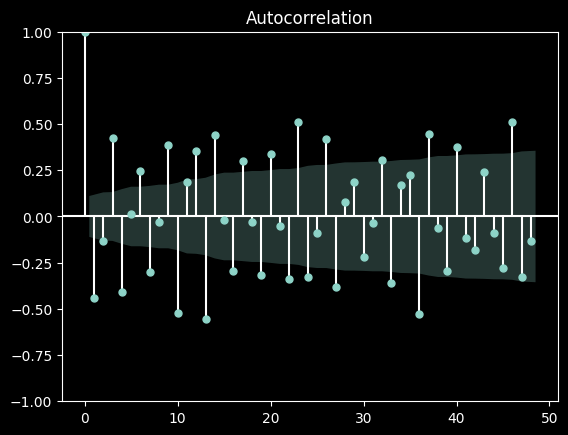

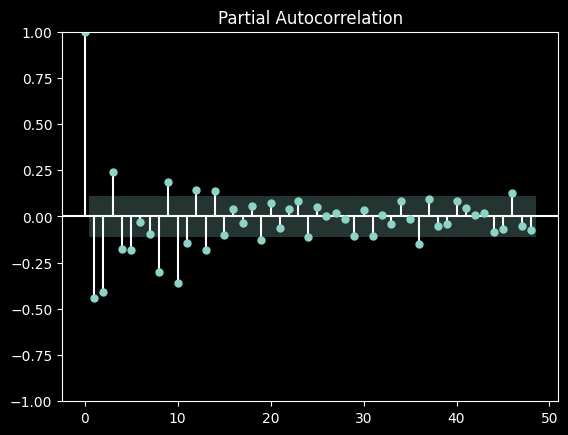

In [46]:
acf = plot_acf(df['Residual'].dropna(),lags=48)
pacf = plot_pacf(df['Residual'].dropna(),lags=48)

In [47]:
from statsmodels.stats.diagnostic import acorr_ljungbox
result = acorr_ljungbox(df['Trend_2'].dropna(), lags=10, return_df=True)
print(result)

       lb_stat     lb_pvalue
1    36.179090  1.799915e-09
2    73.080571  1.351312e-16
3   161.593925  8.301198e-35
4   216.254824  1.198934e-45
5   216.291712  9.252088e-45
6   270.092785  2.072357e-55
7   330.013930  2.328921e-67
8   332.657866  4.538066e-67
9   372.111869  1.211281e-74
10  444.081156  3.822780e-89


In [48]:
from statsmodels.stats.diagnostic import acorr_ljungbox
result = acorr_ljungbox(df['Residual'].dropna(), lags=10, return_df=True)
print(result)

       lb_stat     lb_pvalue
1    61.117513  5.376773e-15
2    66.822574  3.087894e-15
3   124.238773  9.427927e-27
4   176.868818  3.506944e-37
5   176.909706  2.445318e-36
6   195.937991  1.388732e-39
7   225.024452  5.657895e-45
8   225.290154  2.934045e-44
9   273.679194  9.853344e-54
10  362.137619  1.055906e-71


Both Trend and Residual are not random, we use ar/ma/arma</br>
AR Model: Gradual decay in ACF and sharp cut-off in PACF.</br>
MA Model: Sharp cut-off in ACF and gradual decay in PACF.</br>
here we use both ar models for trend and residual, tho we will try arma for residual too.

In [49]:
from statsmodels.tsa.ar_model import AutoReg
train = df.loc[:datetime(2015,1,1)].copy()
test = df.loc[datetime(2015,2,1):].copy()
model = AutoReg(train['Trend_2'].dropna(),lags=2).fit()
print(model.summary())
pred = model.forecast(steps=48)

                            AutoReg Model Results                             
Dep. Variable:                Trend_2   No. Observations:                  269
Model:                     AutoReg(2)   Log Likelihood               -1118.462
Method:               Conditional MLE   S.D. of innovations             15.960
Date:                Mon, 16 Dec 2024   AIC                           2244.924
Time:                        16:33:13   BIC                           2259.273
Sample:                    11-01-1992   HQIC                          2250.688
                         - 01-01-2015                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4075      0.977      0.417      0.677      -1.507       2.322
Trend_2.L1    -0.5439      0.052    -10.476      0.000      -0.646      -0.442
Trend_2.L2    -0.5676      0.052    -10.897      0.0

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [50]:
#model = AutoReg(df['Residual'].dropna(),lags=3).fit()
#predres = model.forecast(steps=6)
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train['Residual'].dropna(),order=(3,0,1)).fit()
predres = model.forecast(steps=48)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [51]:
t = [train['Trend_1'].iloc[-1]]
for i in pred:
    t.append(t[-1]+i)
t.pop(0)
tr = [ train['Trend'].iloc[-1]]
for i in t:
    tr.append(tr[-1]+i)
tr.pop(0)
test['Pred_Trend'] = tr
test['Pred_res'] = predres
test['Pred']=test['Pred_Trend']*test['Seasonality']*test['Pred_res']

<Axes: xlabel='DATE'>

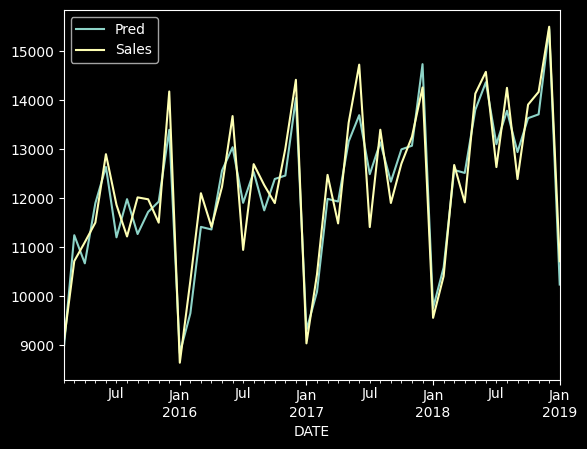

In [52]:
test[['Pred','Sales']].plot()

In [53]:
from sklearn.metrics import root_mean_squared_error as rmse
print("Rmse: ",rmse(test['Pred'],test['Sales']))

Rmse:  499.6901273232693


Forecasting Trend using Regression

<Axes: xlabel='DATE'>

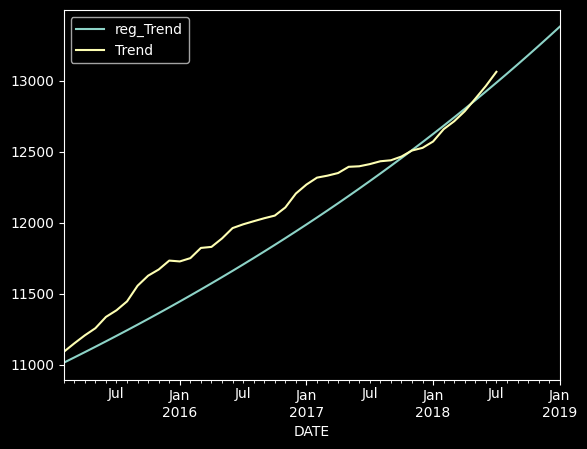

In [54]:
from numpy.polynomial.polynomial import Polynomial
x= np.arange(len(train['Trend'].dropna()))
p=Polynomial.fit(x,train['Trend'].dropna(),deg=6)
pred = p(np.arange(len(train.dropna()['Trend']), len(train.dropna()['Trend'])+48))
test['reg_Trend']=pred
test[['reg_Trend','Trend']].plot()

Rmse:  524.1173833470177


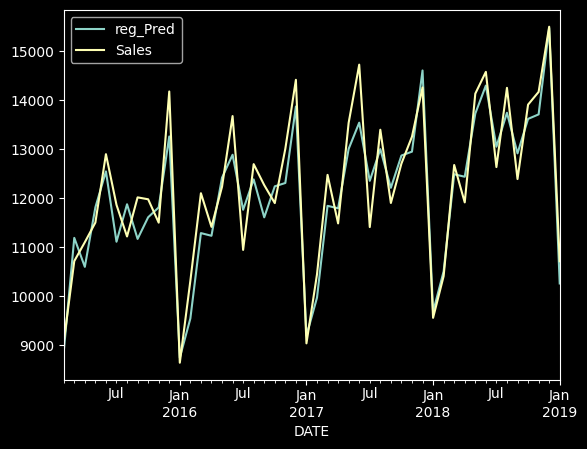

In [55]:
test['reg_Pred'] = test['reg_Trend']*test['Seasonality']*test['Pred_res']
test[['reg_Pred','Sales']].plot()
print("Rmse: ",rmse(test['reg_Pred'],test['Sales']))

Rmse:  501.4672791597834


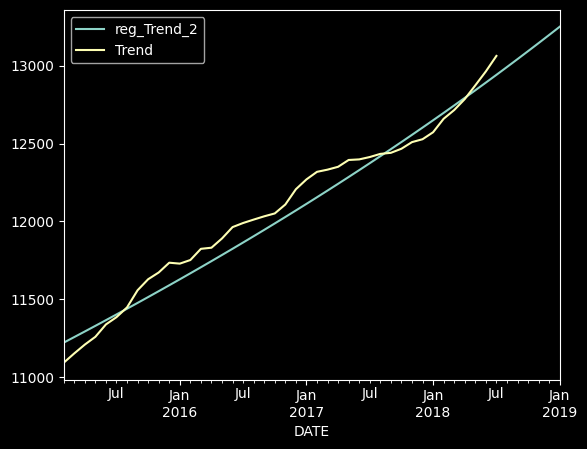

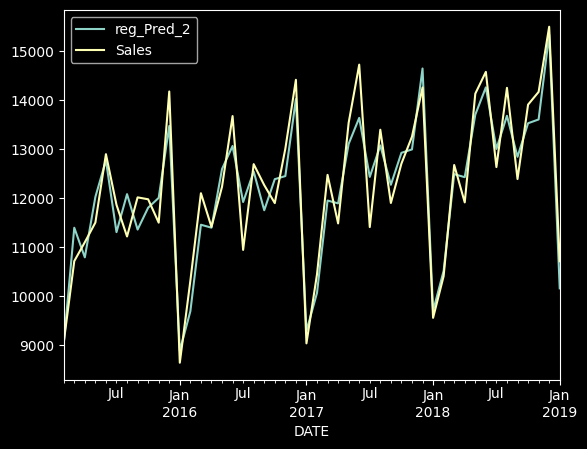

In [56]:
from statsmodels.nonparametric.smoothers_lowess import lowess
trend = train['Trend'].dropna()
smoothed_trend = lowess(trend, np.arange(len(trend)), frac=0.3)
trend_forecast = smoothed_trend[:, 1]
x= np.arange(len(trend_forecast))
p=Polynomial.fit(x,trend_forecast,deg=4)
pred = p(np.arange(len(trend_forecast), len(trend_forecast)+48))
test['reg_Trend_2']=pred
test[['reg_Trend_2','Trend']].plot()
test['reg_Pred_2'] = test['reg_Trend_2']*test['Seasonality']*test['Pred_res']
test[['reg_Pred_2','Sales']].plot()
print("Rmse: ",rmse(test['reg_Pred_2'],test['Sales']))


In [58]:
df['Deseasoned_Sales']= df['Sales']/res.seasonal
df['D_Sales_1'] = df['Deseasoned_Sales']-df['Deseasoned_Sales'].shift(1)
r = adfuller(df['D_Sales_1'].dropna())
r[1]<0.05

True

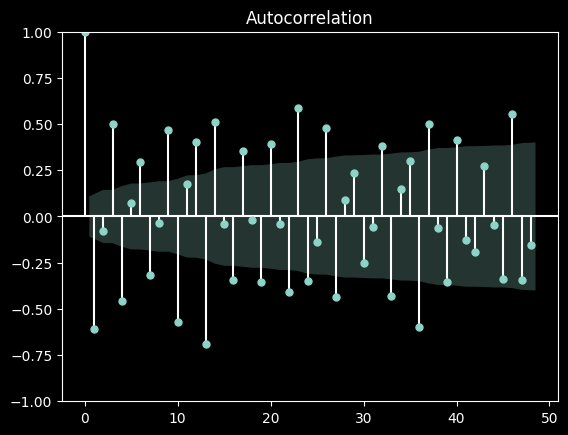

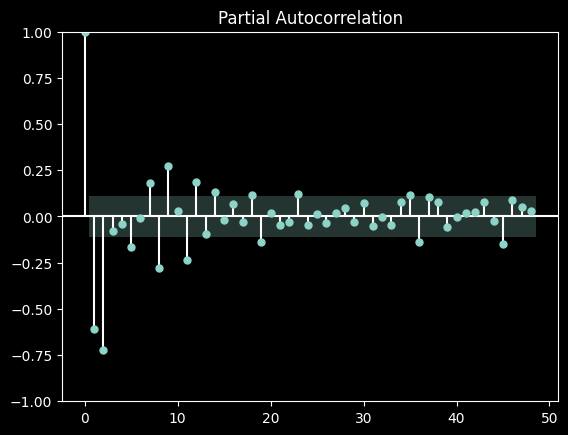

In [60]:
acf = plot_acf(df['D_Sales_1'].dropna(),lags=48)
pacf = plot_pacf(df['D_Sales_1'].dropna(),lags=48)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Rmse:  496.4832898310123


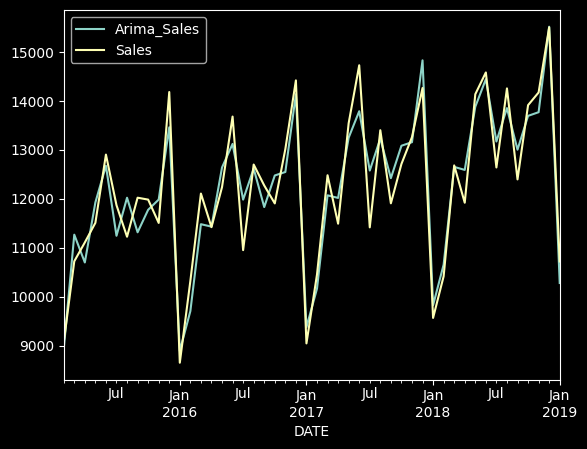

In [72]:
from statsmodels.tsa.arima.model import ARIMA
train = df.loc[:datetime(2015,1,1)].copy()
test = df.loc[datetime(2015,2,1):].copy()
model = ARIMA(train['Trend'], order=(2,2,2),freq='MS').fit()
test['Arima'] = model.forecast(steps=48)
test['Pred_res']=predres
test['Arima_Sales'] = test['Arima']*test['Seasonality']*test['Pred_res']
test[['Arima_Sales','Sales']].plot()
print("Rmse: ",rmse(test['Arima_Sales'],test['Sales']))